In [17]:
import cornac
from cornac.data import Reader
from cornac.datasets import movielens
from cornac.data import Dataset, FeatureModality
from cornac.eval_methods import RatioSplit, StratifiedSplit
from cornac.metrics import RMSE,AUC,NDCG,Precision,Recall
from cornac.models import MF, ItemKNN, UserKNN, NMF, BPR
import pandas as pd
import numpy as np
import random
import math
import seaborn as sns
import matplotlib.pyplot as plt

In [18]:
# reader = Reader()
# # file_name= "./cornac/data_c/indexed_interactions.csv"
# file_name= "biased_movie_lens.csv"
# rating_data_pd = pd.read_csv(
#     file_name,
#     sep=",",
#     header=None,
#     names=["_","userID", "itemID", "Rating", "Timestamp", "movieID","genres","Drama","Children's","Action","War","Documentary","Animation","Comedy","Sci-Fi","Romance","Musical","Western","Crime","Thriller","Adventure","Fantasy","Mystery","Film-Noir","Horror","Gender"],
#     dtype={"userID":int, "itemID":int, "Rating":int, "Timestamp":int, "movieID":int,"Drama":float,"Children's":float,"Action":float,"War":float,"Documentary":float,"Animation":float,"Comedy":float,"Sci-Fi":float,"Romance":float,"Musical":float,"Western":float,"Crime":float,"Thriller":float,"Adventure":float,"Fantasy":float,"Mystery":float,"Film-Noir":float,"Horror":float, "Gender":int}
# )
# # print(rating_data["itemID"].nunique())
# # rating_data = rating_data.drop(columns=rating_data.columns[-1])
# # ,userID,itemID,Rating,Timestamp,movieID,genres,Drama,Children's,Action,War,Documentary,Animation,Comedy,Sci-Fi,Romance,Musical,Western,Crime,Thriller,Adventure,Fantasy,Mystery,Film-Noir,Horror,Gender
# rating_data_pd
# # user id itemid rating and timestamp

,_,userID,itemID,Rating,Timestamp,movieID,genres,Drama,Children's,Action,...,Musical,Western,Crime,Thriller,Adventure,Fantasy,Mystery,Film-Noir,Horror,Gender
0,0,0,0,5,978300760,1193,Drama,1.000000,0.000000,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,1,0,1,3,978302109,661,Animation|Children's|Musical,0.000000,0.333333,0.0,...,0.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,2,0,2,3,978301968,914,Musical|Romance,0.000000,0.000000,0.0,...,0.500000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,3,0,3,4,978300275,3408,Drama,1.000000,0.000000,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,4,0,4,5,978824291,2355,Animation|Children's|Comedy,0.000000,0.333333,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595367,595367,6039,183,2,956715648,1079,Comedy,0.000000,0.000000,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
595368,595368,6039,2506,4,956704746,549,Documentary,0.000000,0.000000,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
595369,595369,6039,754,3,956716374,2021,Fantasy|Sci-Fi,0.000000,0.000000,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0
595370,595370,6039,336,4,956704996,1089,Crime|Thriller,0.000000,0.000000,0.0,...,0.000000,0.0,0.5,0.5,0.0,0.0,0.0,0.0,0.0,0


In [26]:
reader = Reader()
rating_data_pd = pd.read_csv(
    "./cornac/data_c/indexed_interactions.csv",
    sep="\t",
    header=None,
    names=["userID", "itemID", "Rating", "Timestamp"],
)
# print(rating_data["itemID"].nunique())
# rating_data = rating_data.drop(columns=rating_data.columns[-1])
rating_data = rating_data_pd.to_numpy()
rating_data

array([[        0,         0,         5, 978300760],
       [        0,         1,         3, 978302109],
       [        0,         2,         3, 978301968],
       ...,
       [     6039,       365,         5, 956704746],
       [     6039,       152,         4, 956715648],
       [     6039,        26,         4, 956715569]])

In [19]:

# rating_data = rating_data_pd[["userID","itemID","Rating","Timestamp"]].to_numpy()
# rating_data

array([[        0,         0,         5, 978300760],
       [        0,         1,         3, 978302109],
       [        0,         2,         3, 978301968],
       ...,
       [     6039,       754,         3, 956716374],
       [     6039,       336,         4, 956704996],
       [     6039,      1106,         5, 956704887]])

In [20]:
# c=inter_movies[["userID", "itemID", "Rating", "Timestamp"]]
# rating_data= c.to_numpy()
# rating_data.shape

In [27]:
# dataset = Dataset.from_uirt(rating_data, reader=reader)
dataset = rating_data

In [28]:
rating_data_pd

,userID,itemID,Rating,Timestamp
0,0,0,5,978300760
1,0,1,3,978302109
2,0,2,3,978301968
3,0,3,4,978300275
4,0,4,5,978824291
...,...,...,...,...
999606,6039,772,1,956716541
999607,6039,1106,5,956704887
999608,6039,365,5,956704746
999609,6039,152,4,956715648


In [23]:
# movie_data = reader.read(fpath="./data/indexed_movies.csv", sep=",", fmt="UIRT")
# movie_data
movies = pd.read_csv("./cornac/data_c/indexed_movies.csv")

movies = movies.drop(columns=movies.columns[0])
movies[:4]

unique_genres = set("|".join(movies["genres"]).split("|"))
unique_genres = list(unique_genres)

for genre in unique_genres:
    movies[genre] = 0
for index, row in movies.iterrows():
    genres = row["genres"].split("|")
    for genre in genres:
        movies.at[index, genre] = 1

# item_categories = movies[unique_genres]
# unique_iids = rating_data_pd['itemID'].unique()
# movies = movies[movies['itemID'].isin(unique_iids)]
genre = movies[unique_genres]
item_features_numpy = genre.to_numpy()
# print(item_features_numpy.shape)

# item_categories = item_categor
item_features = {
    str(item_id): {"genre_" + str(idx): value for idx, value in enumerate(row)}
    for item_id, row in enumerate(item_features_numpy)
}
ids = list(range(0, 3416))
item_feature_modality = FeatureModality(
    features=item_features_numpy, ids=ids, normalized=True
)


users = pd.read_csv("./cornac/data_c/u_id_mapping.csv", sep="\t")
users = users.drop(columns=users.columns[0])
gender_map = {"M": 0, "F": 1}
users["Gender"] = users["Gender"].map(gender_map)
# unique_uids = rating_data_pd['userID'].unique()

# users = users[users["userID"].isin(unique_uids)]
user_features_numpy = users.to_numpy()
print(user_features_numpy.shape)
user_feature_modality = FeatureModality(
    features=user_features_numpy, name="user", normalized=True, ids=list(range(0, 6040))
)

# print("Example Item Features:")
# for item_id, features in list(item_features.items())[:5]:
#     print(f"Item ID: {item_id}, Features: {features}")

(6040, 2)


In [42]:
inter_movies = pd.merge(rating_data_pd, movies, on="itemID", how="inner")
inter_movies = pd.merge(inter_movies, users, on="userID", how="inner")
inter_movies

,userID,itemID,Rating,Timestamp,movieID,genres,Documentary,Romance,War,Fantasy,...,Animation,Sci-Fi,Children's,Musical,Comedy,Film-Noir,Mystery,Thriller,Crime,Gender
0,0,0,5,978300760,1193,Drama,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,0,1,3,978302109,661,Animation|Children's|Musical,0,0,0,0,...,1,0,1,1,0,0,0,0,0,1
2,0,2,3,978301968,914,Musical|Romance,0,1,0,0,...,0,0,0,1,0,0,0,0,0,1
3,0,3,4,978300275,3408,Drama,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,4,5,978824291,2355,Animation|Children's|Comedy,0,0,0,0,...,1,0,1,0,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999606,6039,772,1,956716541,1091,Comedy,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
999607,6039,1106,5,956704887,1094,Drama|Romance|War,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
999608,6039,365,5,956704746,562,Comedy|Drama,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
999609,6039,152,4,956715648,1096,Drama,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
# new_df = inter_movies.groupby("userID")[unique_genres].sum()
# new_df = pd.merge(new_df, users, on="userID", how="inner")
# new_df = inter_movies.groupby("Gender")[unique_genres].sum()
# new_df


In [43]:
genre_to_remove_m=["Romance", "Drama","Comedy", "Musical"]
genre_to_remove_f=["Action", "War","Thriller", "Horror"]
# upper_bound = inter_movies.shape[0]
indices_to_delete = set()
mask_f = (inter_movies['Gender'] == 1) & (inter_movies[genre_to_remove_f].sum(axis=1) > 0)
mask_m = (inter_movies['Gender'] == 0) & (inter_movies[genre_to_remove_m].sum(axis=1) > 0)
mask_f = inter_movies.index[mask_f]
mask_m = inter_movies.index[mask_m]
upper_bound_m = mask_m.__len__()
upper_bound_f = mask_f.__len__()
for i in range(100000):
    rm=random.randint(0, upper_bound_m-1)
    rf=random.randint(0, upper_bound_f-1)
    indices_to_delete.add(mask_f[rf])
    indices_to_delete.add(mask_m[rm])
            
inter_movies = inter_movies.drop(indices_to_delete, axis=0).reset_index(drop=True)
# sales.drop(sales[sales.CustomerId.isin(badcu)].index.tolist()

In [45]:
inter_movies
unique_iids = inter_movies['userID'].unique()
unique_iids.__len__()
# movies = movies[movies['itemID'].isin(unique_iids)]


6040

In [16]:
# Create a set of all uid values from 0 to 6039
all_uids = set(range(6040))

# Create a set of uid values present in the dataset
present_uids = set(users['userID'])

# Find the missing uid
missing_uids = all_uids - present_uids

print(missing_uids)

{2399}


In [12]:
ratio_split = StratifiedSplit(
    data=dataset,
    test_size=0.2,
    rating_threshold=0.0,
    seed=123,
    verbose=True,
    chrono=True,
    user_features=user_features_numpy[:, 1],
    item_features=item_features_numpy,exclude_unknowns=False
)
rec_50 = cornac.metrics.Recall(k=50)
ndcg_50 = cornac.metrics.NDCG(k=50)
auc = cornac.metrics.AUC()
rmse = cornac.metrics.RMSE()
prec = cornac.metrics.Precision(k=50)


models=[]
alpha_values=[0,0.3,0.5,0.7,0.8]
for i in range(len(alpha_values)):
    model = MF(
    k=20,
    max_iter=50,
    learning_rate=0.00001,
    lambda_reg=0.02,
    seed=123,
    name="alpha="+str(alpha_values[i]),
    backend="pytorch",
    alpha=alpha_values[i],
    optimizer="sgd"
    )    
    models.append(model)

# model = UserKNN(k=20, seed=123)
# model_2 = MF(
# k=10,
# max_iter=50,
# learning_rate=0.0001,
# lambda_reg=0.02,
# seed=123,
# name="alpha="+str(alpha_values[1]),
# backend="pytorch",
# optimizer="sgd",
# alpha=alpha_values[1],
# ) 

# models.append(model)


cornac.Experiment(
    ratio_split, models=models, metrics=[rec_50,ndcg_50,auc,rmse,prec]
).run()

rating_threshold = 0.0
exclude_unknowns = False
::::::::
OrderedDict()
OrderedDict()
::::::::


IndexError: index 6039 is out of bounds for axis 0 with size 6039

In [ ]:
          |   RMSE |    AUC | NDCG@20 | Precision@20 | Recall@20 | Train (s) | Test (s)
--------- + ------ + ------ + ------- + ------------ + --------- + --------- + --------
alpha=0   | 1.0738 | 0.5781 |  0.0651 |       0.0433 |    0.0619 |  265.6354 |   2.8158
alpha=0.3 | 1.0739 | 0.5719 |  0.0625 |       0.0413 |    0.0588 |   89.6387 |   2.9407
alpha=0.5 | 1.0740 | 0.5642 |  0.0579 |       0.0371 |    0.0537 |   89.0614 |   3.5518
alpha=0.7 | 1.0740 | 0.5504 |  0.0444 |       0.0265 |    0.0392 |   87.0882 |   2.8338
alpha=0.8 | 1.0741 | 0.5389 |  0.0300 |       0.0182 |    0.0264 |  672.8500 |   2.8299

new dataset



# item knn no modificatin
        |   RMSE |    AUC | NDCG@20 | Precision@20 | Recall@20 | Train (s) | Test (s)
------- + ------ + ------ + ------- + ------------ + --------- + --------- + --------
UserKNN | 0.9469 | 0.6237 |  0.0103 |       0.0121 |    0.0103 |    1.8950 | 159.0414

# after adding item genres
        |   RMSE |    AUC | NDCG@50 | Precision@50 | Recall@50 | Train (s) | Test (s)
------- + ------ + ------ + ------- + ------------ + --------- + --------- + --------
ItemKNN | 1.0084 | 0.5599 |  0.0173 |       0.0133 |    0.0203 |  156.3764 | 116.4956


# after adding user info
        |   RMSE |    AUC | NDCG@50 | Precision@50 | Recall@50 | Train (s) | Test (s)
------- + ------ + ------ + ------- + ------------ + --------- + --------- + --------
UserKNN | 0.9339 | 0.6007 |  0.0072 |       0.0041 |    0.0154 |   33.4947 | 123.2689


#------------------
          |   RMSE |    AUC | NDCG@20 | Recall@20 | Train (s) | Test (s)
--------- + ------ + ------ + ------- + --------- + --------- + --------
alpha=0   | 1.0809 | 0.5798 |  0.1018 |    0.0635 |  152.5753 |   3.6027
alpha=0.8 | 1.0847 | 0.5844 |  0.1024 |    0.0645 |  211.1065 |   4.3291

          |   RMSE |    AUC | NDCG@20 | Recall@20 | Train (s) | Test (s)
--------- + ------ + ------ + ------- + --------- + --------- + --------
alpha=0.3 | 1.0823 | 0.5800 |  0.1016 |    0.0640 |  772.8089 |   3.6702
alpha=0.5 | 1.0832 | 0.5806 |  0.1018 |    0.0644 |  169.9725 |   4.7815

for (m-f)^2
#------------------


In [ ]:
# choose movies that are only available in the biased subset
unique_iids = rating_data_pd['itemID'].unique()
unique_uids = rating_data_pd['userID'].unique()
movies = movies[movies['itemID'].isin(unique_iids)]
users = users[users["userID"].isin(unique_uids)]

users
# cols_to_select = unique_genres +["itemID", "genres"]
# new_movies = new_movies[cols_to_select]

,userID,Gender
0,0,1
1,1,0
2,2,0
3,3,0
4,4,0
...,...,...
6035,6035,1
6036,6036,1
6037,6037,1
6038,6038,1


In [ ]:
user_ids = users.to_numpy()[:, 0]
item_ids = movies.to_numpy()[:, 2]
user_ids.__len__()

6039

In [ ]:
# get the top_k ratings for all users:
top_k = 50
reco_matrix = np.zeros((len(user_ids), top_k), dtype=int)

for i in range(len(user_ids)):
    reco_items, all_scores = models[0].rank(user_idx=user_ids[i], item_indices=list(item_ids))
    reco_matrix[i] = reco_items[:top_k]

In [ ]:
# # get the top_k ratings for all users:
# top_k = 50
# reco_matrix = np.zeros((len(models), len(user_ids), top_k), dtype=int)


# for u in user_ids:
#     for i in range(len(models)):
#         reco_items, all_scores = models[i].rank(user_idx=u, item_indices=list(item_ids))
#         reco_matrix[i][u] = reco_items[:top_k]

In [ ]:
####Import Metrics####
from cornac.mymetrics.GenrePrecision import GenrePrecision
from cornac.mymetrics.GenreMap import GenreMap
from cornac.mymetrics.GenreMRR import GenreMRR
from cornac.mymetrics.GenreNDCG import GenreNDCG
from cornac.mymetrics.GenreRecall import GenreRecall
from cornac.mymetrics.GenreRPrecision import GenreRPrecision

###intialize them 
gp = GenrePrecision(users, unique_genres)
gr = GenreRecall(users, unique_genres)
gm = GenreMap(users, unique_genres)
gndcg = GenreNDCG(users, unique_genres)
gmrr = GenreMRR(users, unique_genres)

In [ ]:
# for r-precision we wanna take the max of the proportiion of total genre in the movie dataset using ranks
movies_df = movies[unique_genres].div(movies[unique_genres].sum(axis=1), axis=0)
movies_df = movies_df[unique_genres].sum()
new_top_k = math.floor(movies_df.max())


# get the top_k ratings for all users:
reco_matrix_top_r = np.zeros((len(user_ids), new_top_k), dtype=int)

for i in range(len(user_ids)):
    reco_items, all_scores = model.rank(user_idx=user_ids[i], item_indices=list(item_ids))
    reco_matrix_top_r[i] = reco_items[:new_top_k]


grp = GenreRPrecision(users, unique_genres)
# MF_grp = grp.compute(reco_matrix_top_r, movies_df, movies)

In [ ]:
####IR Metrics####
####Precision####
model_gp = gp.compute(reco_matrix, movies)
####IR Metrics####
####Recall####
model_gr = gr.compute(reco_matrix, movies)
####IR Metrics####
####MAP Mean Average Precision####
model_gm = gm.compute(reco_matrix, movies)
####IR Metrics####
####DCG####
model_gdcg = gndcg.compute(reco_matrix, movies)
####IR Metrics####
####MRR####
model_gmrr = gmrr.compute(reco_matrix, movies)
# ####IR Metrics####
# ####Rprecision####
model_grp = grp.compute(reco_matrix_top_r, movies_df, movies)

          Action       War      Drama  Documentary  Children's    Sci-Fi  \
userID                                                                     
0       4.166667  0.333333  18.083333          2.0    1.750000  1.583333   
1       3.416667  0.500000  15.750000          1.0    2.250000  1.333333   
2       3.166667  1.500000  18.250000          1.0    1.083333  2.083333   
3       3.083333  1.000000  13.000000          2.0    2.083333  1.583333   
4       3.666667  1.000000  16.750000          1.0    1.250000  0.583333   
...          ...       ...        ...          ...         ...       ...   
6034    3.583333  0.000000  15.500000          2.0    1.583333  0.583333   
6035    6.083333  0.833333  13.583333          4.0    0.000000  1.500000   
6036    3.583333  1.000000  18.000000          2.0    0.333333  0.250000   
6037    4.500000  0.000000  14.500000          3.0    0.916667  1.500000   
6038    6.666667  0.500000   2.333333          0.0    1.000000  0.333333   

        Rom

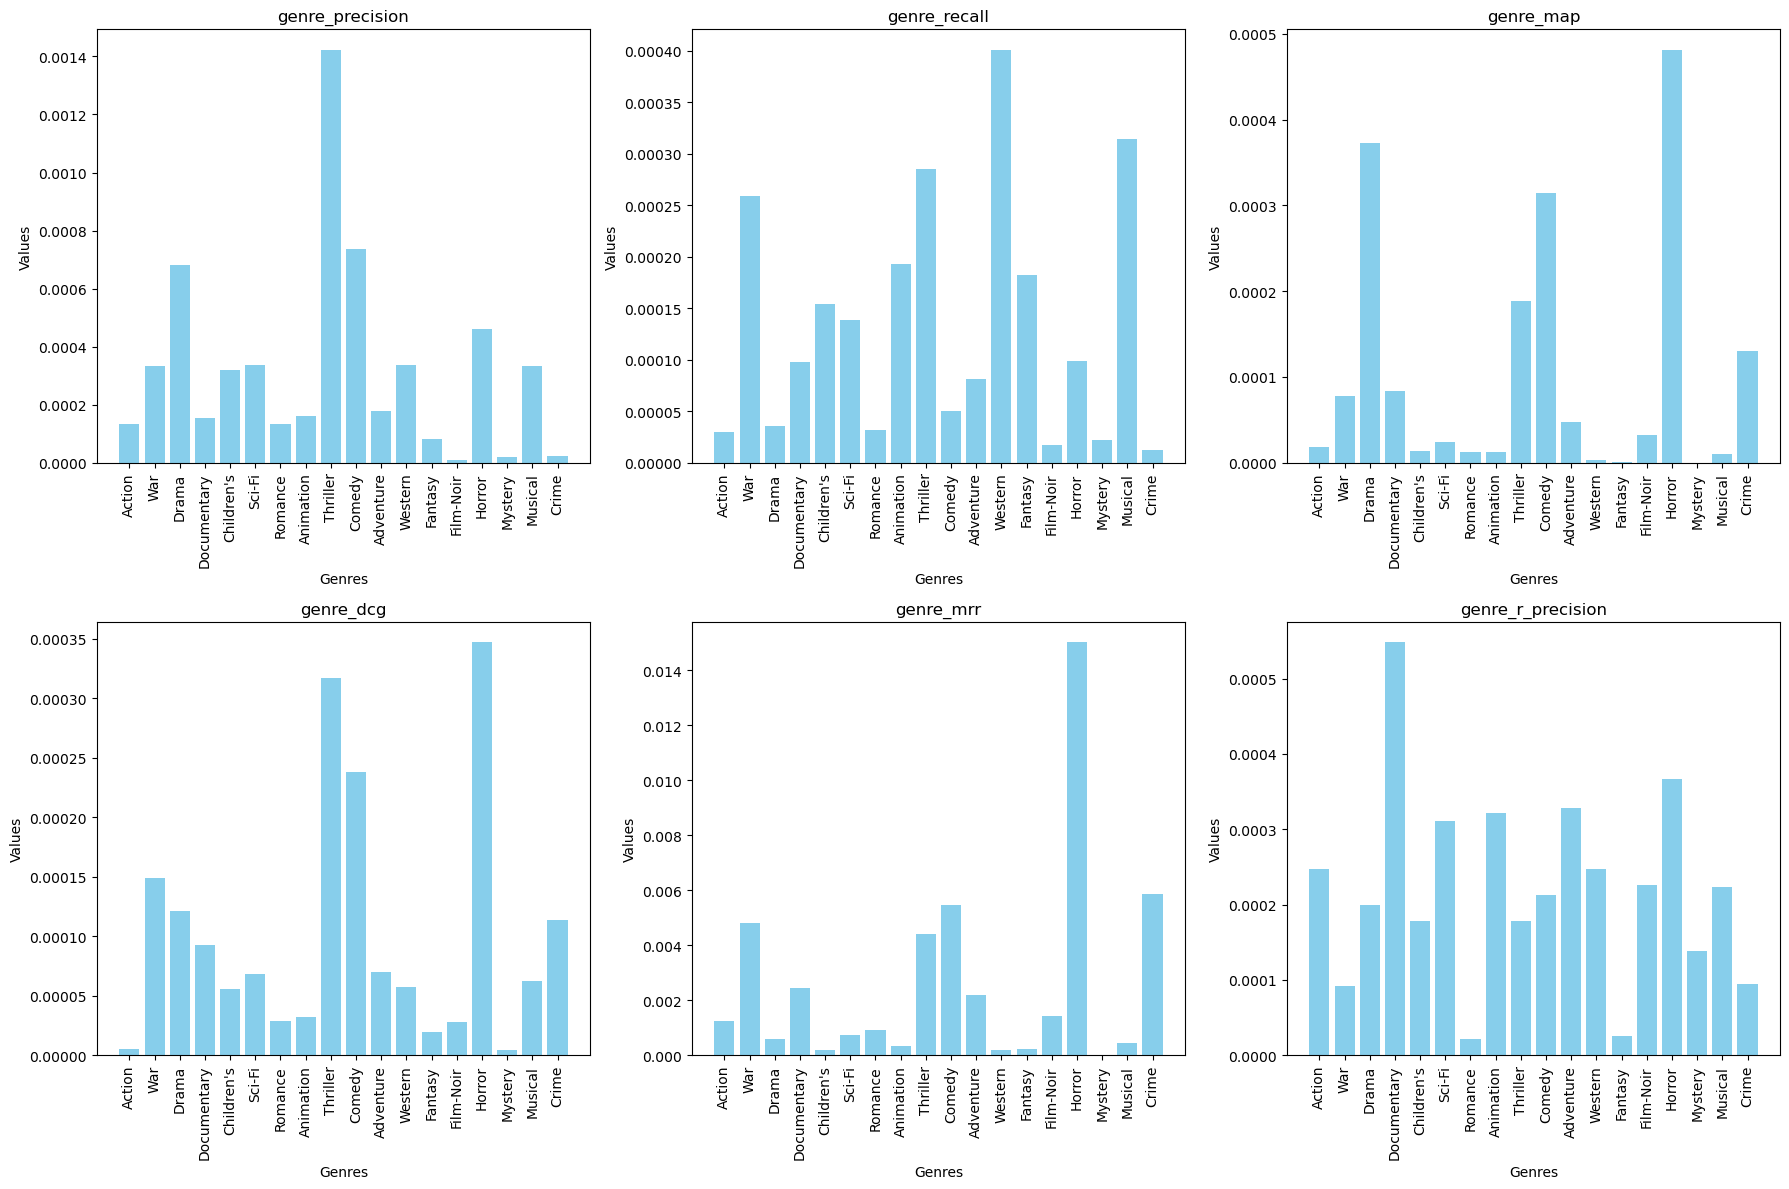

In [ ]:
import matplotlib.pyplot as plt
import numpy as np



matrices =[model_gp,model_gr,model_gm,model_gdcg,model_gmrr,model_grp]

# values2 = matrices[1]
labels = unique_genres
bar_width = 0.25
titles = [ "genre_precision","genre_recall","genre_map","genre_dcg","genre_mrr","genre_r_precision"]


fig, axs = plt.subplots(2, 3, figsize=(18, 12))
axs = axs.flatten()


for i in range(len(titles)):
    axs[i].bar(labels, matrices[i], color="skyblue")
    axs[i].set_title(titles[i])
    axs[i].set_xlabel("Genres")
    axs[i].set_ylabel("Values")
    axs[i].tick_params(axis="x", rotation=90)

# Adjust layout
plt.tight_layout()
plt.show()

In [ ]:
ItemValues = matrices

In [ ]:
UserValues=matrices

In [ ]:
s=0
for i in range(len(titles)):
    s=sum(matrices[i])+s
print(s)

0.062409406372027756


In [ ]:
sum(matrices[1])

0.0024016124379652093

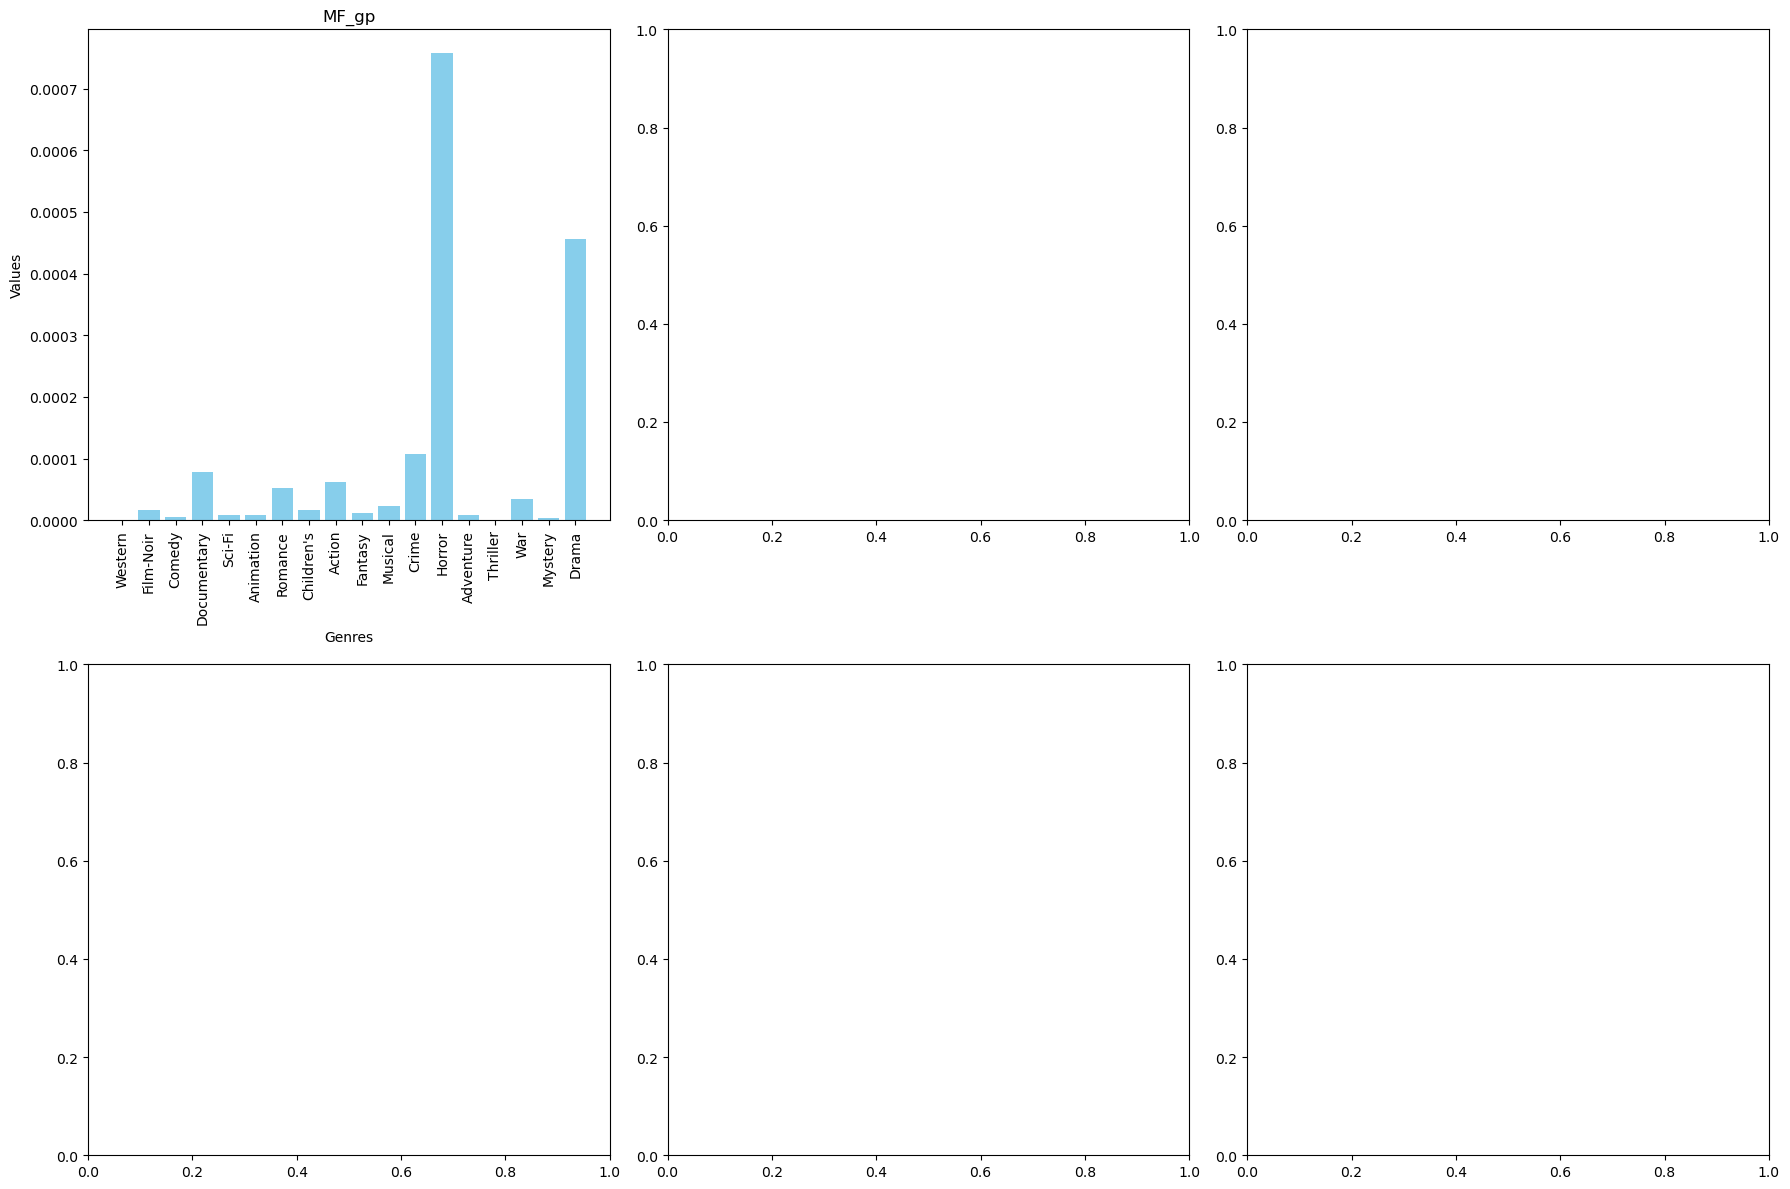

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

matrices = MF_gm


values1 = matrices[0]
# values2 = matrices[1]
# values2 = matrices[2]
# values2 = matrices[3]
# values3 = matrices[2]
labels = unique_genres
bar_width = 0.25
titles = ["MF_gp"]


fig, axs = plt.subplots(2, 3, figsize=(18, 12))
axs = axs.flatten()


for i in range(len(matrices)):
    axs[i].bar(labels, matrices[i], color="skyblue")
    axs[i].set_title(titles[i])
    axs[i].set_xlabel("Genres")
    axs[i].set_ylabel("Values")
    axs[i].tick_params(axis="x", rotation=90)

# Adjust layout
plt.tight_layout()
plt.show()

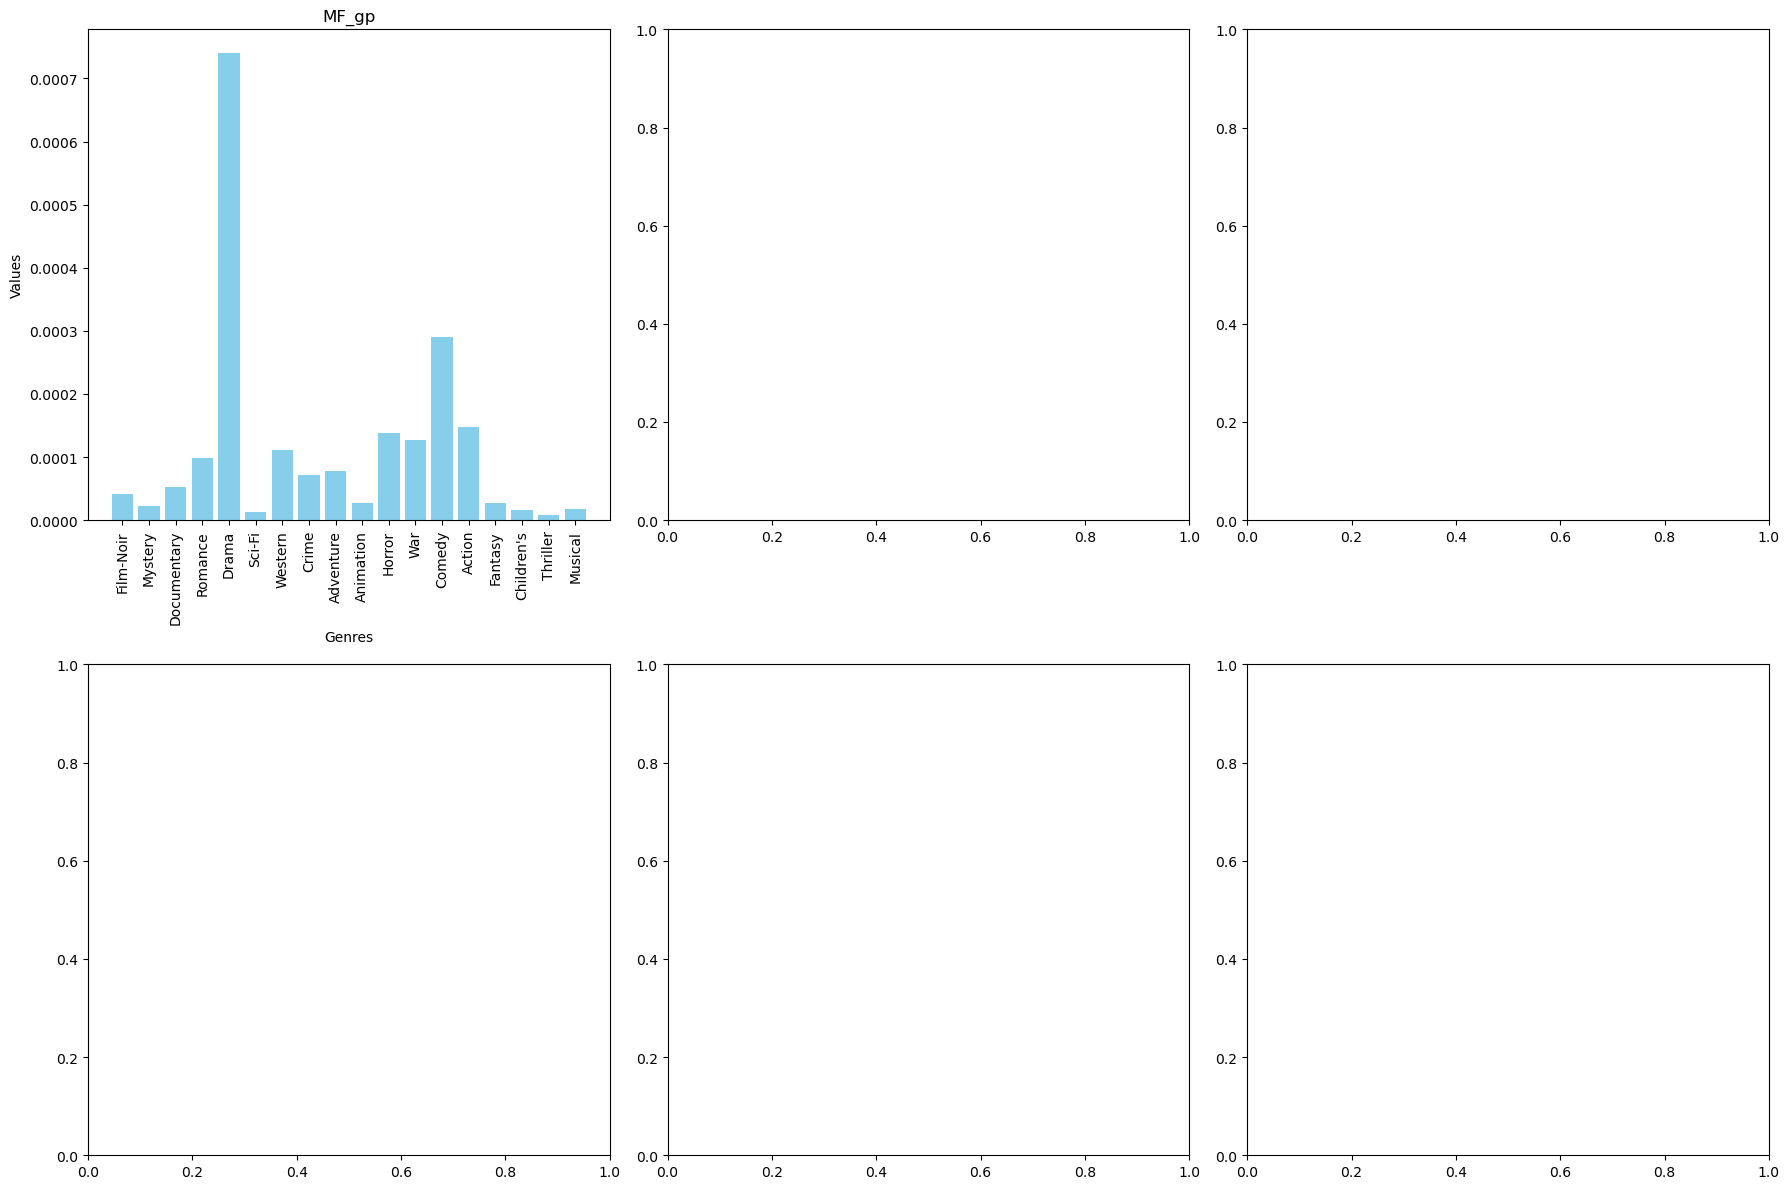

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

matrices = MF_gm


values1 = matrices[0]
# values2 = matrices[1]
# values2 = matrices[2]
# values2 = matrices[3]
# values3 = matrices[2]
labels = unique_genres
bar_width = 0.25
titles = ["MF_gp"]


fig, axs = plt.subplots(2, 3, figsize=(18, 12))
axs = axs.flatten()


for i in range(len(matrices)):
    axs[i].bar(labels, matrices[i], color="skyblue")
    axs[i].set_title(titles[i])
    axs[i].set_xlabel("Genres")
    axs[i].set_ylabel("Values")
    axs[i].tick_params(axis="x", rotation=90)

# Adjust layout
plt.tight_layout()
plt.show()

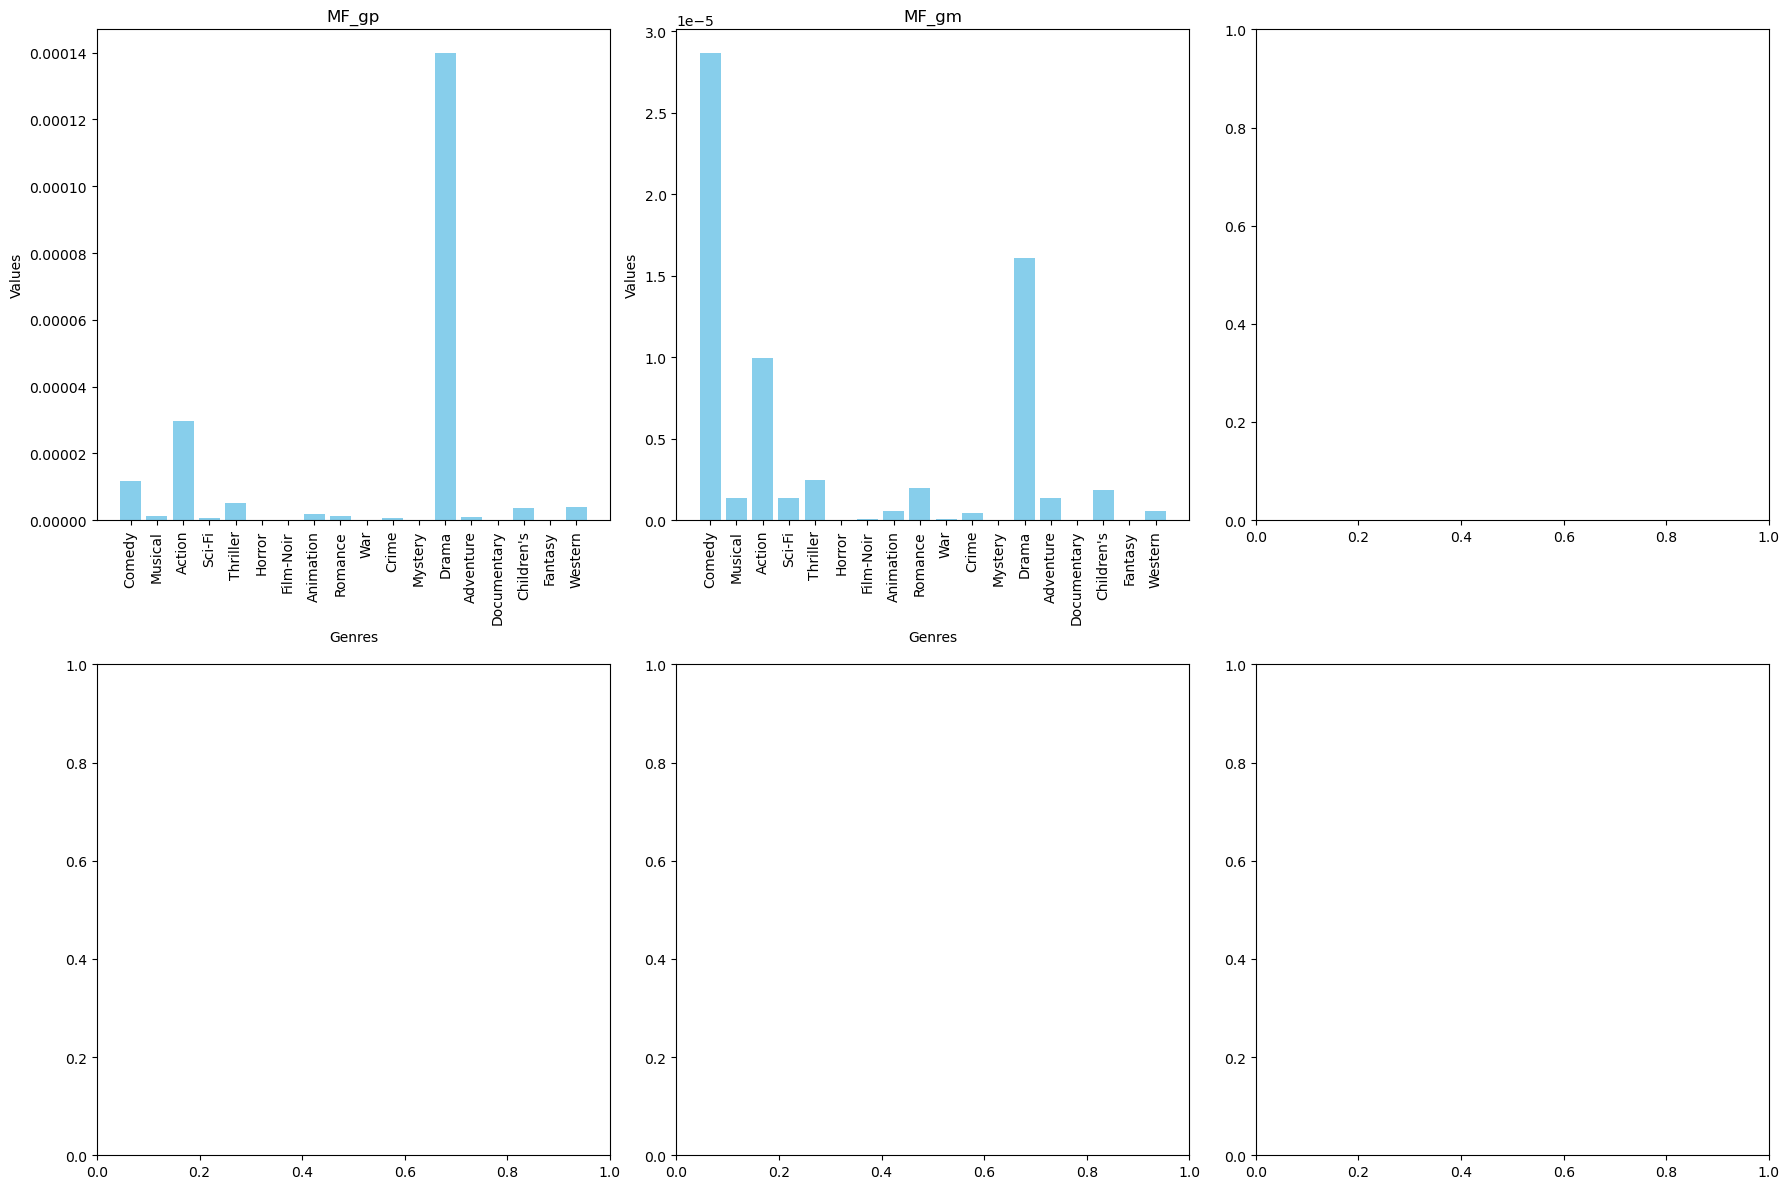

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

matrices = MF_gm


values1 = matrices[0]
values2 = matrices[1]
# values2 = matrices[2]
# values2 = matrices[3]
# values3 = matrices[2]
labels = unique_genres
bar_width = 0.25
titles = ["MF_gp", "MF_gm"]


fig, axs = plt.subplots(2, 3, figsize=(18, 12))
axs = axs.flatten()


for i in range(len(matrices)):
    axs[i].bar(labels, matrices[i], color="skyblue")
    axs[i].set_title(titles[i])
    axs[i].set_xlabel("Genres")
    axs[i].set_ylabel("Values")
    axs[i].tick_params(axis="x", rotation=90)

# Adjust layout
plt.tight_layout()
plt.show()

In [ ]:
print(user_features_numpy[:, 1].shape)

In [ ]:
# Calculate total number of genres
total_genres = len(unique_genres)  # Exclude 'itemID'
# Assuming 'column_name' is the name of the column you want to convert to float
movies[unique_genres] = movies[unique_genres].astype(float)

# Iterate over each row
for index, row in movies.iterrows():
    # Find genres with value 1
    present_genres = [genre for genre in unique_genres if row[genre] == 1]
    num_present_genres = len(present_genres)
    
    # Calculate weight for each present genre
    if num_present_genres > 0:
        weight_per_genre = 1 / num_present_genres
        for genre in present_genres:
            if (movies.at[index,genre]==1):
                movies.at[index, genre] = weight_per_genre

In [ ]:
# mergde_pd = pd.merge(rating_data_pd,users, how="inner", on="userID")
mergde_pd = pd.merge(rating_data_pd,movies, how="inner",on="itemID")
mergde_pd[:5]

,userID,itemID,Rating,Timestamp,movieID,genres,Comedy,Sci-Fi,Animation,Adventure,...,Film-Noir,Horror,Drama,Musical,Children's,Fantasy,War,Thriller,Crime,Western
0,0,0,5,978300760,1193,Drama,0.000000,0.0,0.000000,0.0,...,0.0,0.0,1.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
1,0,1,3,978302109,661,Animation|Children's|Musical,0.000000,0.0,0.333333,0.0,...,0.0,0.0,0.0,0.333333,0.333333,0.0,0.0,0.0,0.0,0.0
2,0,2,3,978301968,914,Musical|Romance,0.000000,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.500000,0.000000,0.0,0.0,0.0,0.0,0.0
3,0,3,4,978300275,3408,Drama,0.000000,0.0,0.000000,0.0,...,0.0,0.0,1.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
4,0,4,5,978824291,2355,Animation|Children's|Comedy,0.333333,0.0,0.333333,0.0,...,0.0,0.0,0.0,0.000000,0.333333,0.0,0.0,0.0,0.0,0.0


In [ ]:
user_genre_means = mergde_pd.groupby('userID')[unique_genres].mean()
user_genre_means


,Comedy,Musical,Action,Sci-Fi,Thriller,Horror,Film-Noir,Animation,Romance,War,Crime,Mystery,Drama,Adventure,Documentary,Children's,Fantasy,Western
userID,,,,,,,,,,,,,,,,,,
0,0.129560,0.109119,0.028302,0.018868,0.031447,0.000000,0.000000,0.132704,0.053459,0.015723,0.012579,0.000000,0.292453,0.024214,0.000000,0.132704,0.018868,0.000000
1,0.098191,0.000000,0.169121,0.043798,0.093669,0.006460,0.001938,0.000000,0.069380,0.040568,0.034884,0.006460,0.382041,0.043798,0.000000,0.000000,0.001938,0.007752
2,0.355229,0.003922,0.153268,0.033987,0.040850,0.016340,0.000000,0.016993,0.029085,0.007843,0.000000,0.006536,0.075817,0.176144,0.000000,0.016993,0.011438,0.055556
3,0.000000,0.000000,0.376190,0.126190,0.067460,0.051587,0.000000,0.000000,0.025397,0.034921,0.015873,0.000000,0.132540,0.086508,0.000000,0.011905,0.023810,0.047619
4,0.188131,0.005471,0.069024,0.031566,0.092172,0.029461,0.005471,0.008418,0.072811,0.012626,0.047138,0.015152,0.360690,0.015152,0.030303,0.011364,0.000000,0.005051
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6035,0.182395,0.015184,0.067661,0.079955,0.081494,0.047372,0.008071,0.016160,0.060867,0.018656,0.025619,0.016273,0.293056,0.035473,0.010698,0.024794,0.006794,0.009478
6036,0.167492,0.007838,0.047607,0.078960,0.176568,0.019802,0.017327,0.001650,0.041419,0.032756,0.034653,0.023102,0.311056,0.012541,0.002475,0.009488,0.004950,0.010314
6037,0.366667,0.000000,0.035000,0.010000,0.000000,0.050000,0.000000,0.075000,0.110000,0.060000,0.000000,0.000000,0.258333,0.010000,0.000000,0.025000,0.000000,0.000000


In [ ]:
users

,userID,Gender
0,0,1
1,1,0
2,2,0
3,3,0
4,4,0
...,...,...
6035,6035,1
6036,6036,1
6037,6037,1
6038,6038,1


In [ ]:
useer= pd.merge(user_genre_means, users, on="userID", how="inner")
user_genre_gender = useer.groupby('Gender')[unique_genres].mean()
user_genre_gender


,Comedy,Musical,Action,Sci-Fi,Thriller,Horror,Film-Noir,Animation,Romance,War,Crime,Mystery,Drama,Adventure,Documentary,Children's,Fantasy,Western
Gender,,,,,,,,,,,,,,,,,,
0,0.203637,0.013770,0.112976,0.070855,0.091484,0.044618,0.009522,0.01604,0.049907,0.031133,0.032804,0.015763,0.206559,0.047763,0.006794,0.022604,0.011497,0.012273
1,0.228915,0.023042,0.069847,0.041291,0.077945,0.032999,0.008491,0.01950,0.090118,0.024085,0.026827,0.016482,0.247989,0.036050,0.007716,0.031251,0.011143,0.006308


In [ ]:
rating_data_pd

,userID,itemID,Rating,Timestamp
0,0,0,5,978300760
1,0,1,3,978302109
2,0,2,3,978301968
3,0,3,4,978300275
4,0,4,5,978824291
...,...,...,...,...
999606,6039,772,1,956716541
999607,6039,1106,5,956704887
999608,6039,365,5,956704746
999609,6039,152,4,956715648


In [ ]:
# inter_movies
z= inter_movies[["userID","itemID","Gender"]]
mergz= pd.merge(z,movies, on="itemID",how="left")
mergz
user_genre_gender = mergz.groupby('Gender')[unique_genres].mean()
user_genre_gender


,Drama,Children's,Action,War,Documentary,Animation,Comedy,Sci-Fi,Romance,Musical,Western,Crime,Thriller,Adventure,Fantasy,Mystery,Film-Noir,Horror
Gender,,,,,,,,,,,,,,,,,,
0,0.128797,0.025067,0.155463,0.025427,0.011284,0.016803,0.134711,0.094746,0.033451,0.009417,0.017207,0.034410,0.128323,0.065184,0.013813,0.020436,0.012184,0.073275
1,0.325799,0.048793,0.000383,0.000110,0.010828,0.027534,0.336074,0.024512,0.112172,0.033176,0.008371,0.018635,0.000429,0.022856,0.013784,0.010287,0.006089,0.000168


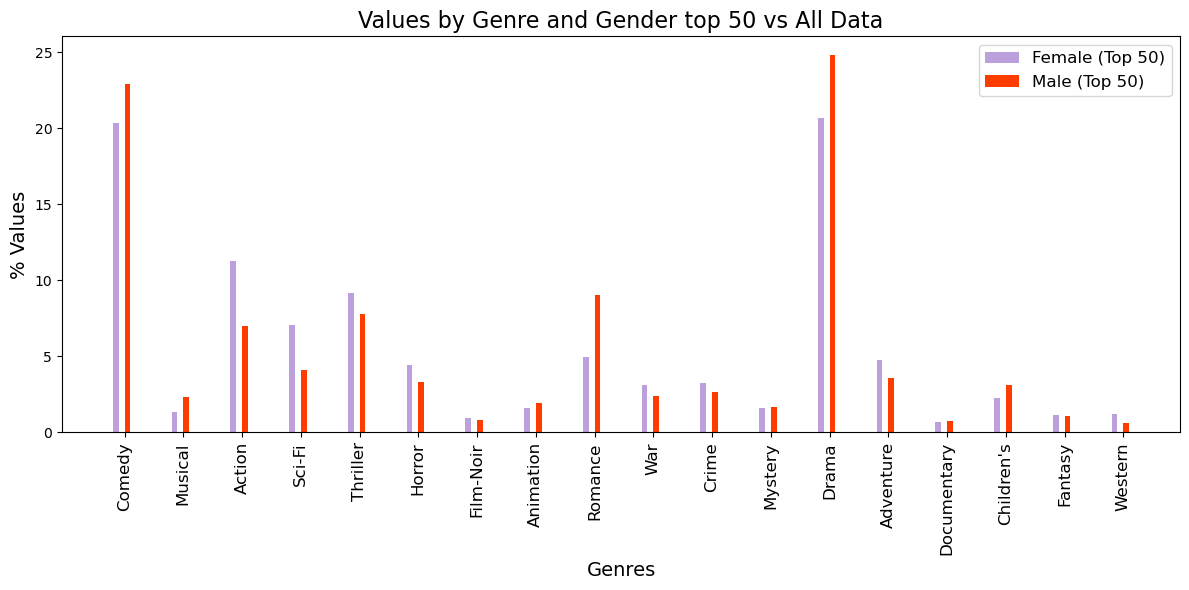

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting
x = np.arange(len(unique_genres))  # the label locations
bar_width = 0.1  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))  # Set the figure size

# Plot the data
rects1 = ax.bar(x - 3*bar_width/2, user_genre_gender.iloc[0]*100, bar_width, label='Female (Top 50)', color="#bca0dc")
rects2 = ax.bar(x + bar_width/2, user_genre_gender.iloc[1]*100, bar_width, label='Male (Top 50)', color="#ff3c00")

# rects3 = ax.bar(x - 5*bar_width/2, gender_genre_weights_topk_over.iloc[0]*100, bar_width, label='Female (over sampled )',color="#4d9fff")
# rects4 = ax.bar(x + 5*bar_width/2, gender_genre_weights_topk_over.iloc[1]*100, bar_width, label='Male (over sampled )',color="#78eaff")

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Genres', fontsize=14)
ax.set_ylabel('% Values', fontsize=14)
ax.set_title('Values by Genre and Gender top 50 vs All Data', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(unique_genres, rotation=90, fontsize=12)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()


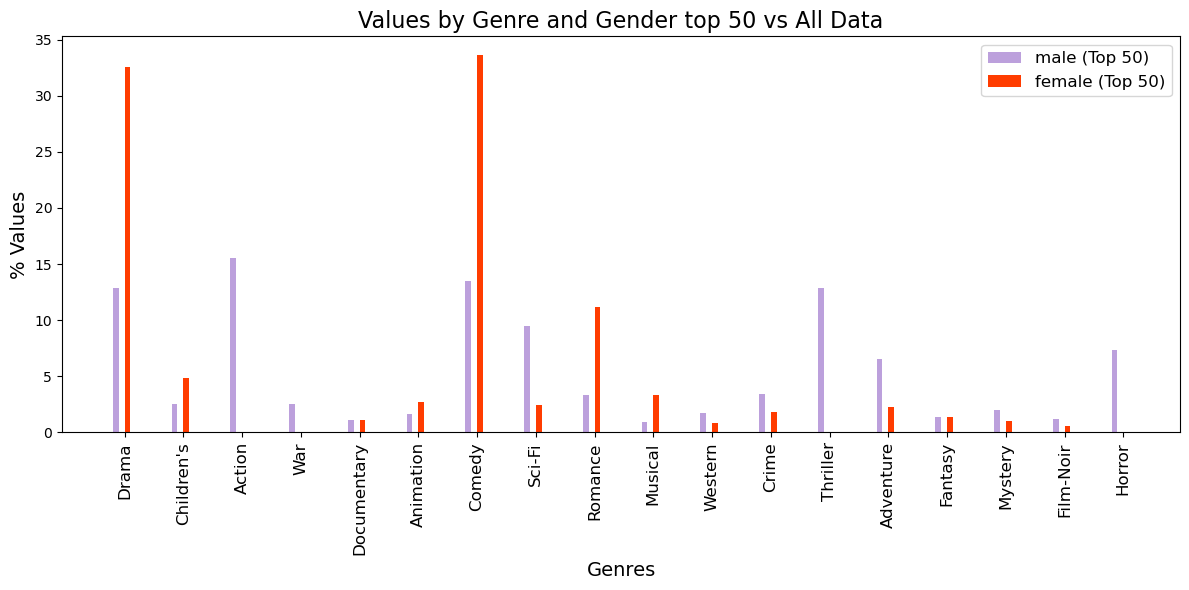

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting
x = np.arange(len(unique_genres))  # the label locations
bar_width = 0.1  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))  # Set the figure size

# Plot the data
rects1 = ax.bar(x - 3*bar_width/2, user_genre_gender.iloc[0]*100, bar_width, label='male (Top 50)', color="#bca0dc")
rects2 = ax.bar(x + bar_width/2, user_genre_gender.iloc[1]*100, bar_width, label='female (Top 50)', color="#ff3c00")

# rects3 = ax.bar(x - 5*bar_width/2, gender_genre_weights_topk_over.iloc[0]*100, bar_width, label='Female (over sampled )',color="#4d9fff")
# rects4 = ax.bar(x + 5*bar_width/2, gender_genre_weights_topk_over.iloc[1]*100, bar_width, label='Male (over sampled )',color="#78eaff")

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Genres', fontsize=14)
ax.set_ylabel('% Values', fontsize=14)
ax.set_title('Values by Genre and Gender top 50 vs All Data', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(unique_genres, rotation=90, fontsize=12)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()


In [ ]:
# inter_movies["itemID"].nunique()

3416

In [ ]:
# Generate userID array
user_ids = np.arange(1, reco_matrix[0].shape[0] + 1).repeat(reco_matrix[0].shape[1])

# Flatten movie_ids array
flat_movie_ids = reco_matrix[0].flatten()

# Create DataFrame
df = pd.DataFrame({
    'userID': user_ids,
    'itemID': flat_movie_ids
})

mepd= pd.merge(df,movies, on="itemID", how="inner")
mepd= pd.merge(mepd,users, on="userID", how="inner")
user_genre_gender_1 = mepd.groupby('Gender')[unique_genres].mean()

user_genre_gender_1
# Print the DataFrame


,Comedy,Musical,Action,Sci-Fi,Thriller,Horror,Film-Noir,Animation,Romance,War,Crime,Mystery,Drama,Adventure,Documentary,Children's,Fantasy,Western
Gender,,,,,,,,,,,,,,,,,,
0,0.193773,0.051764,0.119993,0.043264,0.073814,0.01,0.006667,0.055268,0.051667,0.006667,0.034932,0.0,0.220162,0.039931,0.0,0.048601,0.0,0.043498
1,0.193782,0.051819,0.119934,0.043272,0.073723,0.01,0.006667,0.055322,0.051667,0.006667,0.034942,0.0,0.220100,0.039939,0.0,0.048655,0.0,0.043513


In [ ]:
# Generate userID array
user_ids = np.arange(1, reco_matrix[1].shape[0] + 1).repeat(reco_matrix[1].shape[1])

# Flatten movie_ids array
flat_movie_ids = reco_matrix[1].flatten()

# Create DataFrame
df = pd.DataFrame({
    'userID': user_ids,
    'itemID': flat_movie_ids
})

mepd= pd.merge(df,movies, on="itemID", how="inner")
mepd= pd.merge(mepd,users, on="userID", how="inner")
user_genre_gender_2 = mepd.groupby('Gender')[unique_genres].mean()

user_genre_gender_2
# Print the DataFrame


,Comedy,Musical,Action,Sci-Fi,Thriller,Horror,Film-Noir,Animation,Romance,War,Crime,Mystery,Drama,Adventure,Documentary,Children's,Fantasy,Western
Gender,,,,,,,,,,,,,,,,,,
0,0.194886,0.055998,0.127428,0.041921,0.075072,0.01,0.006667,0.055028,0.051667,0.006665,0.033588,0.0,0.210647,0.038583,0.0,0.048361,0.0,0.043487
1,0.194945,0.056069,0.127436,0.041890,0.075048,0.01,0.006667,0.055053,0.051667,0.006663,0.033557,0.0,0.210546,0.038545,0.0,0.048386,0.0,0.043528


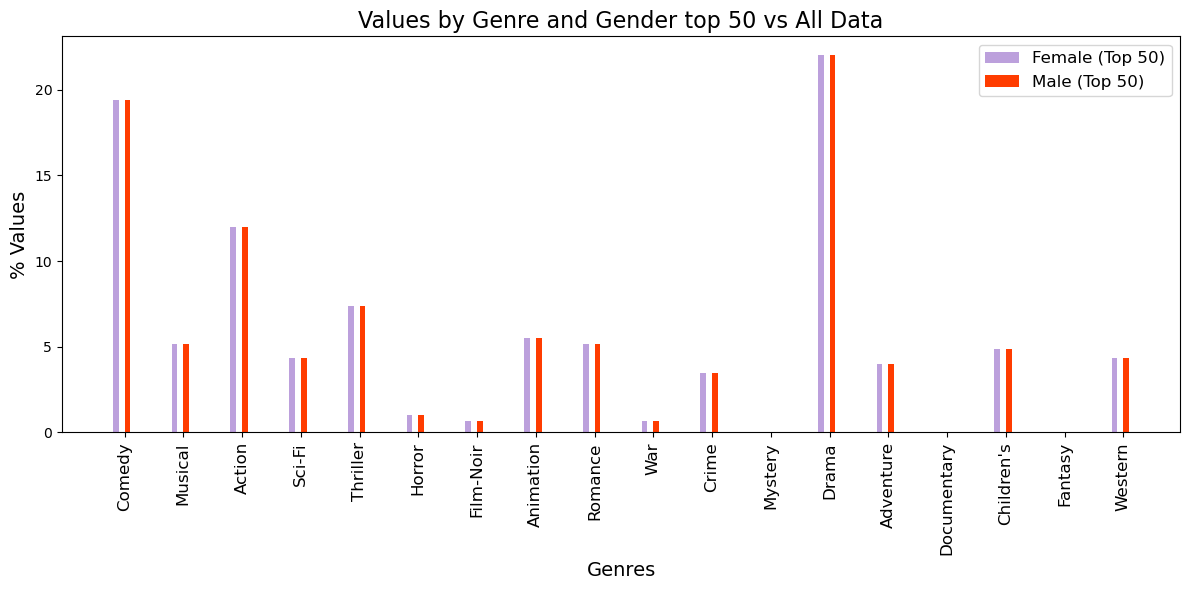

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting
x = np.arange(len(unique_genres))  # the label locations
bar_width = 0.1  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))  # Set the figure size

# Plot the data
rects1 = ax.bar(x - 3*bar_width/2, user_genre_gender_1.iloc[0]*100, bar_width, label='Female (Top 50)', color="#bca0dc")
rects2 = ax.bar(x + bar_width/2, user_genre_gender_1.iloc[1]*100, bar_width, label='Male (Top 50)', color="#ff3c00")

# rects3 = ax.bar(x - 5*bar_width/2, gender_genre_weights_topk_over.iloc[0]*100, bar_width, label='Female (over sampled )',color="#4d9fff")
# rects4 = ax.bar(x + 5*bar_width/2, gender_genre_weights_topk_over.iloc[1]*100, bar_width, label='Male (over sampled )',color="#78eaff")

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Genres', fontsize=14)
ax.set_ylabel('% Values', fontsize=14)
ax.set_title('Values by Genre and Gender top 50 vs All Data', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(unique_genres, rotation=90, fontsize=12)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()


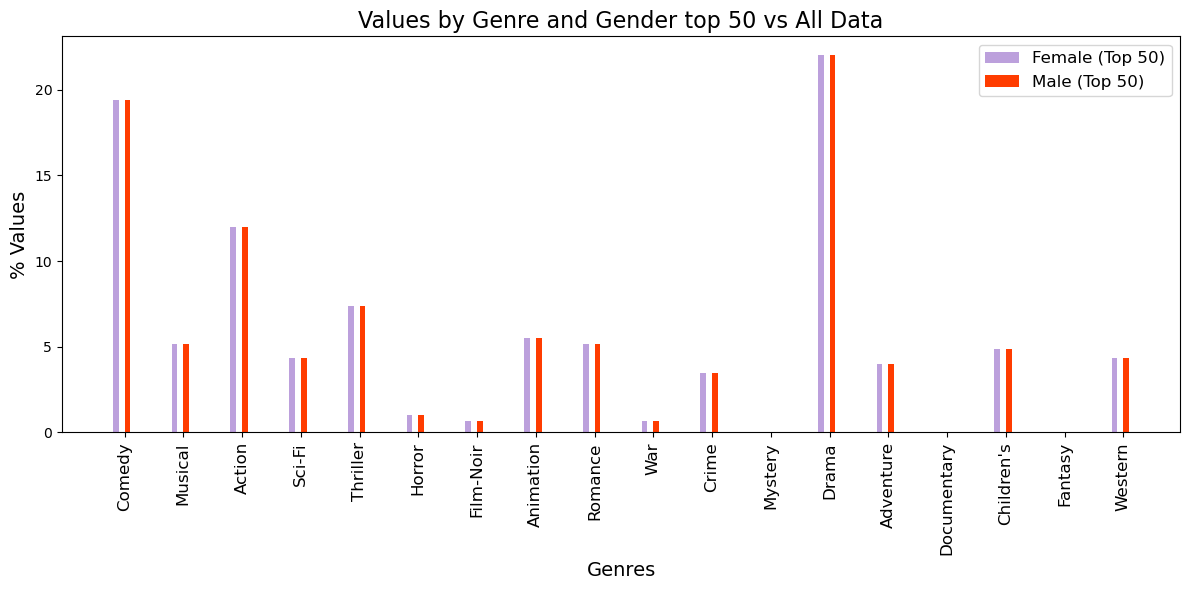

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting
x = np.arange(len(unique_genres))  # the label locations
bar_width = 0.1  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))  # Set the figure size

# Plot the data
rects1 = ax.bar(x - 3*bar_width/2, user_genre_gender_1.iloc[0]*100, bar_width, label='Female (Top 50)', color="#bca0dc")
rects2 = ax.bar(x + bar_width/2, user_genre_gender_1.iloc[1]*100, bar_width, label='Male (Top 50)', color="#ff3c00")

# rects3 = ax.bar(x - 5*bar_width/2, gender_genre_weights_topk_over.iloc[0]*100, bar_width, label='Female (over sampled )',color="#4d9fff")
# rects4 = ax.bar(x + 5*bar_width/2, gender_genre_weights_topk_over.iloc[1]*100, bar_width, label='Male (over sampled )',color="#78eaff")

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Genres', fontsize=14)
ax.set_ylabel('% Values', fontsize=14)
ax.set_title('Values by Genre and Gender top 50 vs All Data', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(unique_genres, rotation=90, fontsize=12)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()


In [ ]:
##use 0 and 0.5 as alpha

In [ ]:
# Generate userID array
user_ids = np.arange(1, reco_matrix.shape[0] + 1).repeat(reco_matrix.shape[1])

# Flatten movie_ids array
flat_movie_ids = reco_matrix.flatten()

# Create DataFrame
df = pd.DataFrame({
    'userID': user_ids,
    'itemID': flat_movie_ids
})

mepd= pd.merge(df,movies, on="itemID", how="inner")
mepd= pd.merge(mepd,users, on="userID", how="inner")
user_genre_gender_1 = mepd.groupby('Gender')[unique_genres].mean()

user_genre_gender_1
# Print the DataFrame


,Comedy,Sci-Fi,Animation,Adventure,Documentary,Mystery,Romance,Action,Film-Noir,Horror,Drama,Musical,Children's,Fantasy,War,Thriller,Crime,Western
Gender,,,,,,,,,,,,,,,,,,
0,0.216307,0.041355,0.028848,0.024509,0.004355,0.014292,0.055443,0.051728,0.002722,0.029869,0.352402,0.044639,0.030163,0.008037,0.010180,0.049310,0.011159,0.024683
1,0.217560,0.041353,0.028322,0.023816,0.004602,0.014469,0.055884,0.051610,0.002857,0.029601,0.354431,0.043354,0.029623,0.007807,0.009886,0.049617,0.011101,0.024106


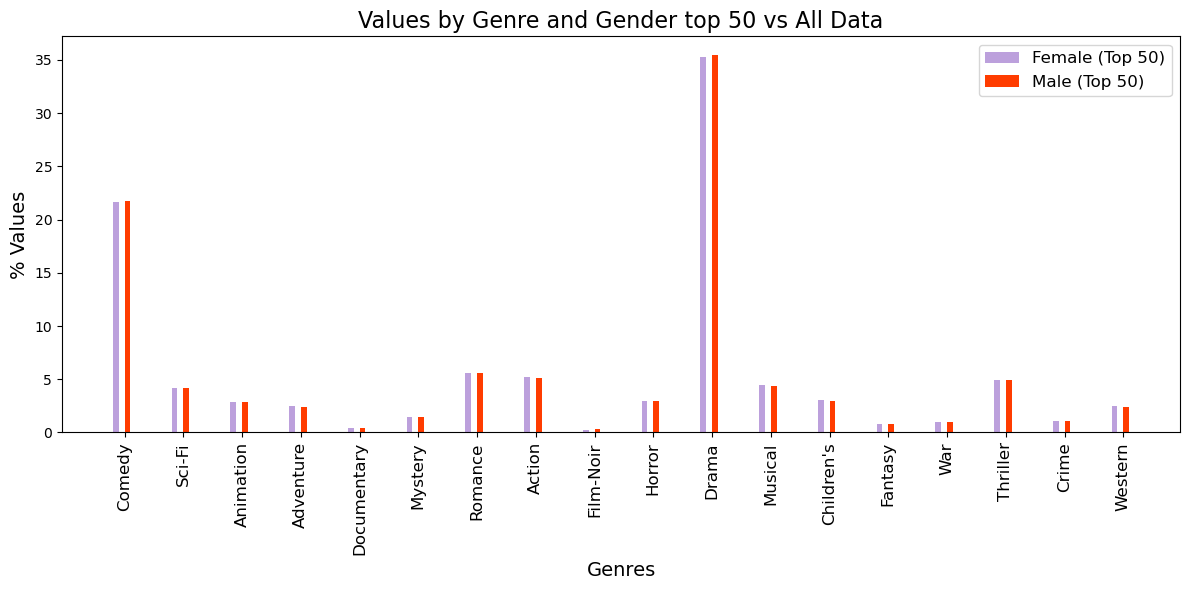

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting
x = np.arange(len(unique_genres))  # the label locations
bar_width = 0.1  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))  # Set the figure size

# Plot the data
rects1 = ax.bar(x - 3*bar_width/2, user_genre_gender_1.iloc[0]*100, bar_width, label='Female (Top 50)', color="#bca0dc")
rects2 = ax.bar(x + bar_width/2, user_genre_gender_1.iloc[1]*100, bar_width, label='Male (Top 50)', color="#ff3c00")

# rects3 = ax.bar(x - 5*bar_width/2, gender_genre_weights_topk_over.iloc[0]*100, bar_width, label='Female (over sampled )',color="#4d9fff")
# rects4 = ax.bar(x + 5*bar_width/2, gender_genre_weights_topk_over.iloc[1]*100, bar_width, label='Male (over sampled )',color="#78eaff")

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Genres', fontsize=14)
ax.set_ylabel('% Values', fontsize=14)
ax.set_title('Values by Genre and Gender top 50 vs All Data', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(unique_genres, rotation=90, fontsize=12)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()


In [ ]:
inter_movies

,userID,itemID,Rating,Timestamp,movieID,genres,Drama,Children's,Action,War,...,Musical,Western,Crime,Thriller,Adventure,Fantasy,Mystery,Film-Noir,Horror,Gender
0,0,0,5,978300760,1193,Drama,1.000000,0.000000,0.0,0.000000,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,0,1,3,978302109,661,Animation|Children's|Musical,0.000000,0.333333,0.0,0.000000,...,0.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,0,2,3,978301968,914,Musical|Romance,0.000000,0.000000,0.0,0.000000,...,0.500000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,0,3,4,978300275,3408,Drama,1.000000,0.000000,0.0,0.000000,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,0,4,5,978824291,2355,Animation|Children's|Comedy,0.000000,0.333333,0.0,0.000000,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595367,6039,183,2,956715648,1079,Comedy,0.000000,0.000000,0.0,0.000000,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
595368,6039,2506,4,956704746,549,Documentary,0.000000,0.000000,0.0,0.000000,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
595369,6039,754,3,956716374,2021,Fantasy|Sci-Fi,0.000000,0.000000,0.0,0.000000,...,0.000000,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0
595370,6039,336,4,956704996,1089,Crime|Thriller,0.000000,0.000000,0.0,0.000000,...,0.000000,0.0,0.5,0.5,0.0,0.0,0.0,0.0,0.0,0


In [46]:
inter_movies.to_csv('biased_movie_lens.csv')